<a href="https://colab.research.google.com/github/nadroj0-0/Applied-Deep-Learning-COMP019-GROUP/blob/luke/Final-Presentation-Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [19]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
QUANTILES = [0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.975]
NUM_QUANTILES = len(QUANTILES)
SEQ_LENGTH = 28
PRED_LENGTH = 28
NUM_ITEMS = 200        # Small subset for rapid prototyping, scale up for production
BATCH_SIZE = 1024
EPOCHS = 5

# Data Download and trim

In [20]:
def download_m5_data():
    print("Downloading dataset from Hugging Face...")
    df = pd.read_csv("https://huggingface.co/datasets/kashif/M5/resolve/main/sales_train_evaluation.csv")
    calendar = pd.read_csv("https://huggingface.co/datasets/kashif/M5/resolve/main/calendar.csv")
    prices = pd.read_csv("https://huggingface.co/datasets/kashif/M5/resolve/main/sell_prices.csv")
    print(f"✅ Download complete. Sales shape: {df.shape}")
    return df, calendar, prices

def trim_data(df: pd.DataFrame, num_items: int) -> pd.DataFrame:
    # NEW: Filter for CA_3 items first
    print("Filtering for store CA_3...")
    df = df[df['store_id'] == 'CA_3'].copy()

    print(f"Selecting the TOP {num_items} highest-volume items in CA_3...")
    day_cols = [c for c in df.columns if c.startswith('d_')]
    df['total_sales_volume'] = df[day_cols].sum(axis=1)
    trimmed_df = df.sort_values('total_sales_volume', ascending=False).head(num_items).copy()
    trimmed_df = trimmed_df.drop(columns=['total_sales_volume'])
    return trimmed_df

sales, calendar, prices = download_m5_data()
sales_trimmed = trim_data(sales, NUM_ITEMS)


✅ Download complete. Sales shape: (30490, 1947)
Filtering for store CA_3...
Selecting the TOP 200 highest-volume items in CA_3...


# Data Preprocessing for LSTM (Tensors)

In [21]:
# --- REPLACEMENT FOR CELL 3 ---
def preprocess_lstm_data_with_revenue_weights(df: pd.DataFrame, prices_df: pd.DataFrame):
    print("Building windows and calculating REVENUE-based item weights...")

    # 1. Fast Price Merge: Calculate average price per item/store to avoid RAM explosion
    avg_prices = prices_df.groupby(['item_id', 'store_id'])['sell_price'].mean().reset_index()
    df = df.merge(avg_prices, on=['item_id', 'store_id'], how='left')

    # Fill any missing prices with the dataset median just in case
    global_median_price = prices_df['sell_price'].median()
    df['sell_price'] = df['sell_price'].fillna(global_median_price)

    # Encode categorical hierarchy
    for col in ['state_id', 'store_id', 'cat_id', 'dept_id']:
        df[f'{col}_int'] = df[col].astype('category').cat.codes

    day_cols = [c for c in df.columns if c.startswith('d_')]
    data_array = df[day_cols].values.astype(np.float32)
    num_items, total_days = data_array.shape

    day_of_week = (np.arange(total_days) + 5) % 7
    test_days = 28
    train_array = data_array[:, :-test_days]

    # 2. Calculate Revenue Weights (Volume * Price)
    item_volumes = train_array.sum(axis=1)
    item_revenues = item_volumes * df['sell_price'].values
    item_weights = item_revenues / item_revenues.sum() # Normalize so weights sum to 1.0

    X_train_list, y_train_list, w_train_list = [], [], []
    X_test_list, y_test_list, w_test_list = [], [], []

    for item_idx in range(num_items):
        static_feats = [df.iloc[item_idx][f'{c}_int'] for c in ['state_id', 'store_id', 'cat_id', 'dept_id']]
        i_weight = item_weights[item_idx]

        # Train
        for t in range(train_array.shape[1] - SEQ_LENGTH):
            sales_window = train_array[item_idx, t : t + SEQ_LENGTH].reshape(-1, 1)
            dow_window = day_of_week[t : t + SEQ_LENGTH].reshape(-1, 1)
            f_block = np.tile(static_feats, (SEQ_LENGTH, 1))
            X_train_list.append(np.hstack([sales_window, f_block, dow_window]))
            y_train_list.append(train_array[item_idx, t + SEQ_LENGTH])
            w_train_list.append(i_weight)

        # Test
        sales_seed = data_array[item_idx, -(test_days + SEQ_LENGTH) : -test_days].reshape(-1, 1)
        dow_seed = day_of_week[-(test_days + SEQ_LENGTH) : -test_days].reshape(-1, 1)
        f_block_test = np.tile(static_feats, (SEQ_LENGTH, 1))
        X_test_list.append(np.hstack([sales_seed, f_block_test, dow_seed]))
        y_test_list.append(data_array[item_idx, -test_days:])
        w_test_list.append(i_weight)

    return {
        "X_train": torch.tensor(np.array(X_train_list), dtype=torch.float32),
        "y_train": torch.tensor(np.array(y_train_list), dtype=torch.float32),
        "w_train": torch.tensor(np.array(w_train_list), dtype=torch.float32),
        "X_test": torch.tensor(np.array(X_test_list), dtype=torch.float32),
        "y_test": torch.tensor(np.array(y_test_list), dtype=torch.float32),
        "w_test": torch.tensor(np.array(w_test_list), dtype=torch.float32)
    }

# Execute function, passing in BOTH the trimmed sales and the prices dataframe
tensors = preprocess_lstm_data_with_revenue_weights(sales_trimmed, prices)

train_dataset = TensorDataset(tensors["X_train"].to(DEVICE), tensors["y_train"].to(DEVICE), tensors["w_train"].to(DEVICE))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

Building windows and calculating REVENUE-based item weights...


# Hierarchichal LSTM Architecture and Loss

In [22]:
class WeightedPinballLoss(nn.Module):
    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = quantiles

    def forward(self, preds, target, weights):
        if target.dim() == 1:
            target = target.unsqueeze(1)
        if weights.dim() == 1:
            weights = weights.unsqueeze(1)

        losses = []
        for i, q in enumerate(self.quantiles):
            errors = target - preds[:, i:i+1]
            # Standard pinball calculation
            loss_q = torch.max((q - 1) * errors, q * errors)
            losses.append(loss_q)

        # Combine quantiles and apply item weights via broadcasting
        stacked_losses = torch.cat(losses, dim=1)
        weighted_losses = stacked_losses * weights

        return weighted_losses.mean(dim=0).sum()


class HMLSTM(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=128, num_layers=2, num_quantiles=9, dropout_rate=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout_rate)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, num_quantiles) # Changed to 9
        )
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        return self.fc(out)

## Hierarchichal LSTM Training

In [23]:
def train_nn_model(model, name):
    print(f"\n🚀 Training {name}...")
    criterion = WeightedPinballLoss(QUANTILES)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        start_time = time.time()

        # Now unpacking 3 variables from the dataloader
        for batch_X, batch_y, batch_w in train_loader:
            optimizer.zero_grad(set_to_none=True)
            preds = model(batch_X)
            loss = criterion(preds, batch_y, batch_w) # Pass weights to loss
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        print(f"   Epoch {epoch+1}/{EPOCHS} | Avg Weighted Loss: {avg_loss:.6f} | Time: {time.time()-start_time:.2f}s")
    return model

bhm_model = train_nn_model(HMLSTM(input_dim=6).to(DEVICE), "Hierarchichal LSTM")


🚀 Training Hierarchichal LSTM...
   Epoch 1/5 | Avg Weighted Loss: 0.164127 | Time: 13.99s
   Epoch 2/5 | Avg Weighted Loss: 0.087111 | Time: 13.05s
   Epoch 3/5 | Avg Weighted Loss: 0.083175 | Time: 12.87s
   Epoch 4/5 | Avg Weighted Loss: 0.081652 | Time: 12.34s
   Epoch 5/5 | Avg Weighted Loss: 0.081131 | Time: 12.25s


# LightGBM Training

In [24]:
print("\n🚀 Training LightGBM Quantile Models...")
X_train_lgb = tensors["X_train"][:, :, 0].numpy()
y_train_lgb = tensors["y_train"].numpy()
w_train_lgb = tensors["w_train"].numpy() # Extract weights

# Pass the weights directly into the LightGBM Dataset
lgb_train = lgb.Dataset(X_train_lgb, y_train_lgb, weight=w_train_lgb)
lgbm_models = {}

target_quantiles = [0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.975]
lgbm_models = {}

for q in target_quantiles:
    params = {
        'objective': 'quantile',
        'alpha': q,
        'metric': 'quantile',
        'learning_rate': 0.05,
        'verbose': -1
    }
    lgbm_models[q] = lgb.train(params, lgb_train, num_boost_round=100)

print("   LightGBM Training Complete.")


🚀 Training LightGBM Quantile Models...
   LightGBM Training Complete.


# Unified Recursive Forecasting & Visualization (The Comparison)

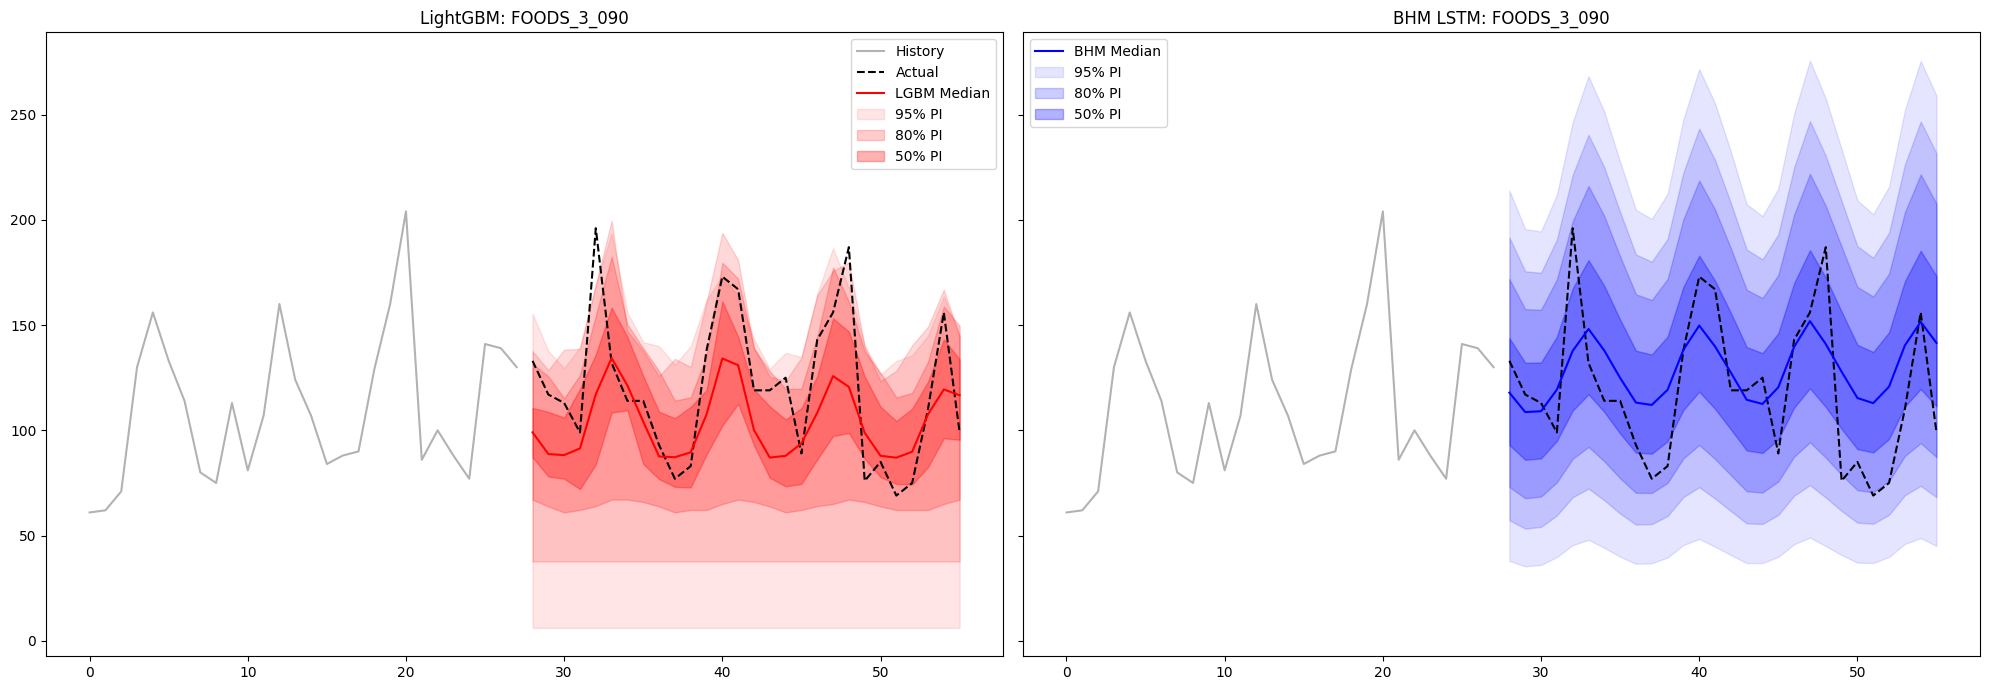

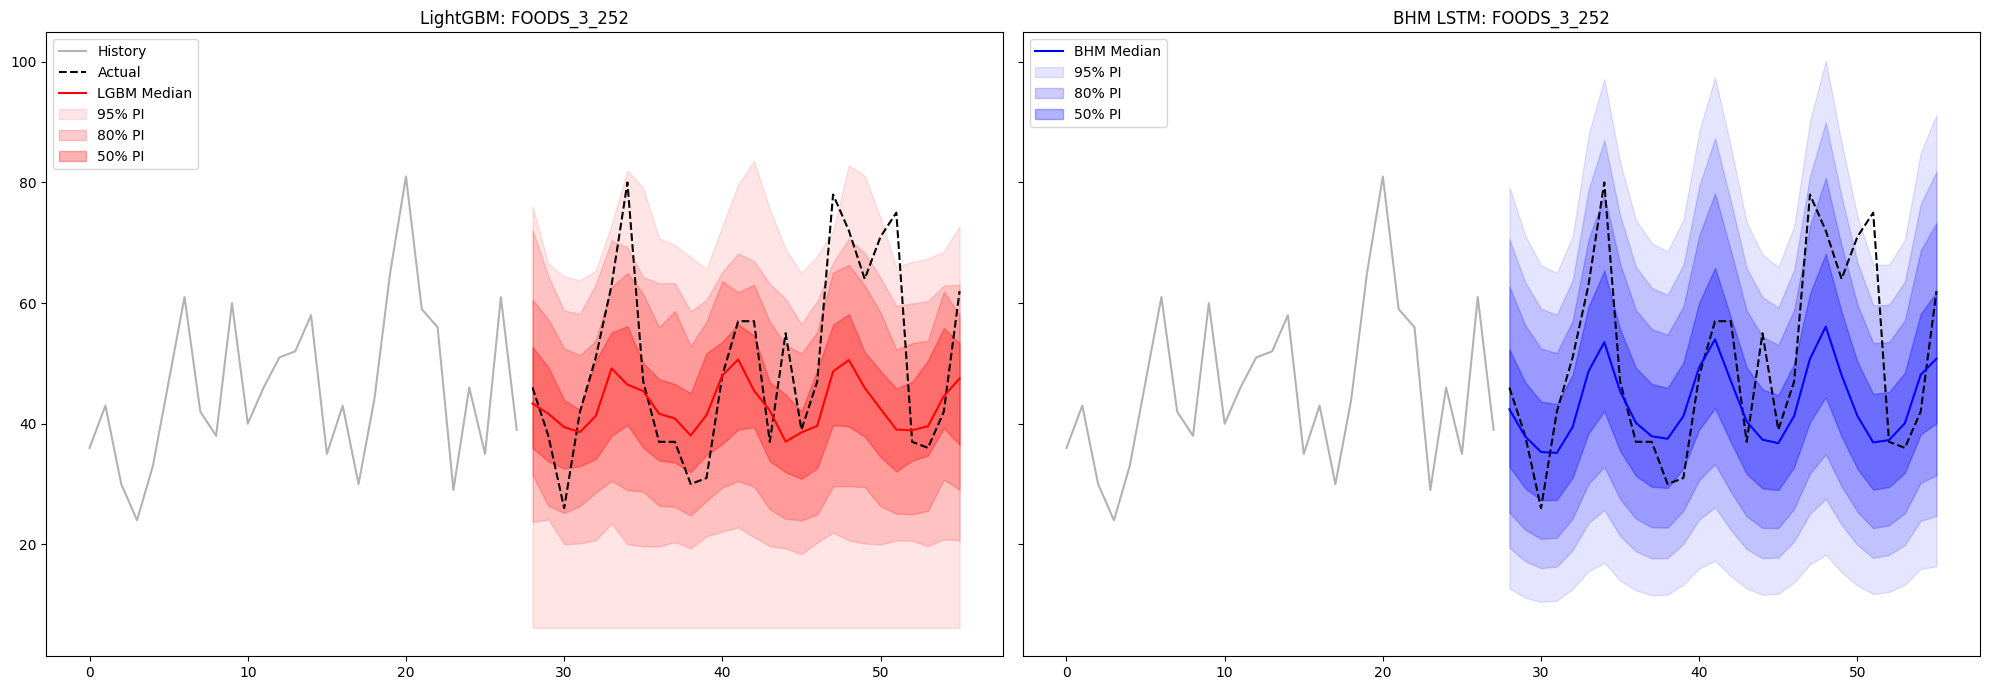

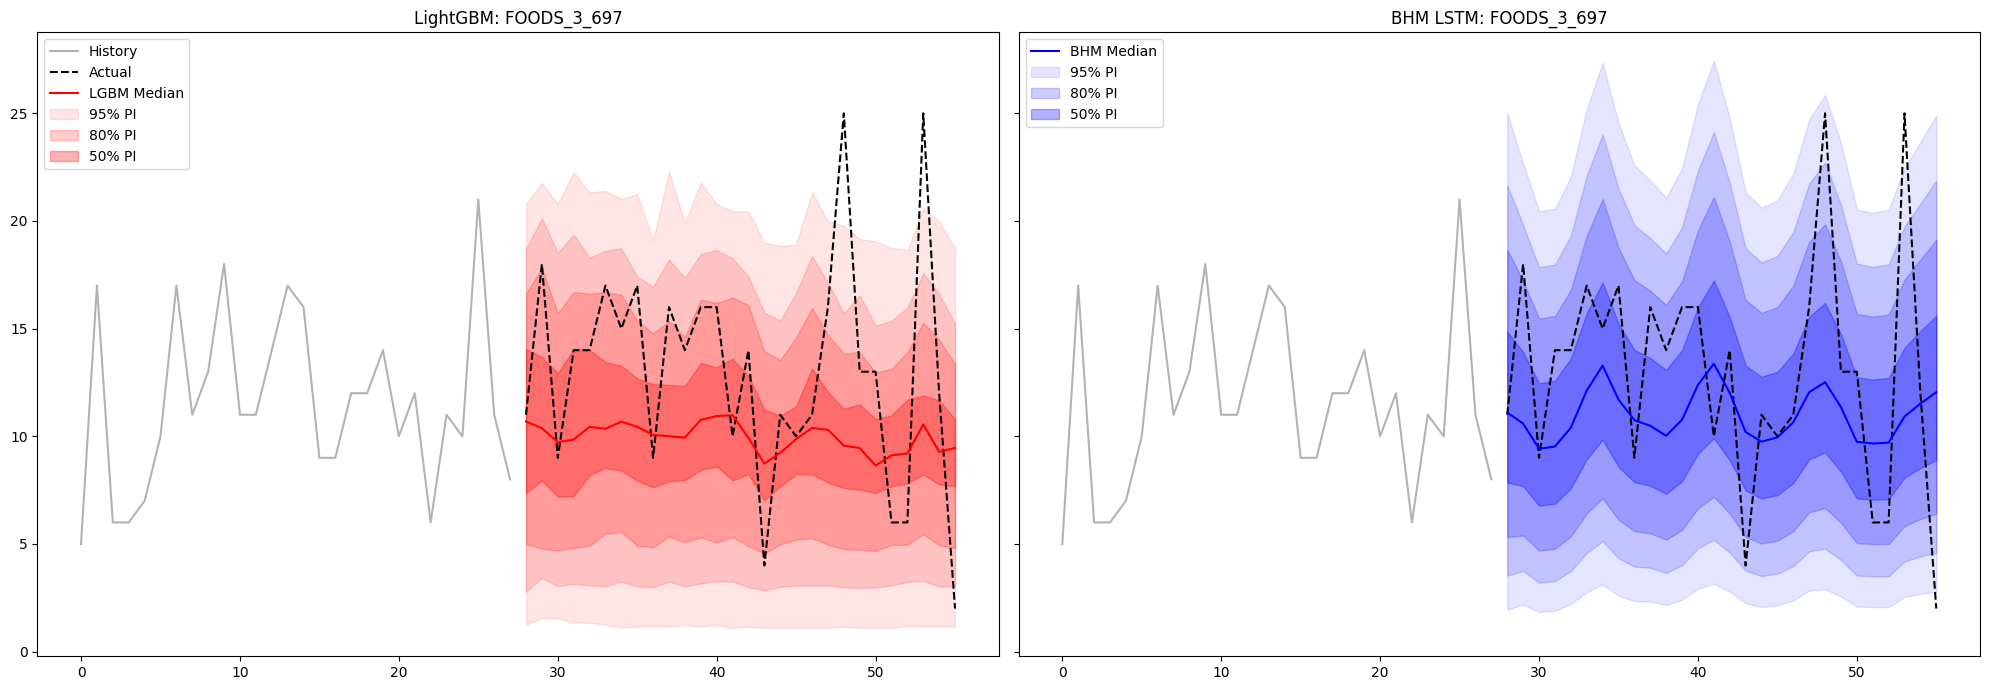

In [27]:
def predict_28_days_nn_quantiles(model, initial_history, device):
    model.eval()
    current_window = initial_history.copy()
    predictions = [] # Will store all 7 quantiles
    idx_median = QUANTILES.index(0.5)
    static_ids = current_window[0, 1:5]

    for step in range(28):
        x_tensor = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_quantiles = model(x_tensor).cpu().numpy()[0]

        # Prevent negative predictions across all quantiles
        pred_quantiles = np.maximum(0.0, pred_quantiles)
        predictions.append(pred_quantiles)

        # We must use the median (50th percentile) to feed back into the autoregressive loop
        median_pred = pred_quantiles[idx_median]

        # Increment Day of Week
        last_dow = current_window[-1, 5]
        new_dow = (last_dow + 1) % 7

        new_row = np.concatenate([[median_pred], static_ids, [new_dow]])
        current_window = np.vstack([current_window[1:], new_row])

    return np.array(predictions) # Returns shape (28, 7)
def predict_28_days_lgb_quantiles(models_dict, initial_history):
    current_window = initial_history[:, 0].copy()
    predictions = {q: [] for q in models_dict.keys()}

    for step in range(28):
        features = current_window[-28:].reshape(1, -28)

        step_preds = {}
        for q, model in models_dict.items():
            pred = model.predict(features)[0]
            step_preds[q] = max(0.0, pred)
            predictions[q].append(step_preds[q])

        # We must use the median (0.5) to feed back into the autoregressive loop
        current_window = np.append(current_window, step_preds[0.5])

    return predictions

def compare_models_side_by_side(item_idx=0):
    seed_full = tensors["X_test"][item_idx].numpy()
    actual = tensors["y_test"][item_idx].numpy()
    historical = seed_full[:, 0]

    # NEW: Get the actual item name string
    item_id = sales_trimmed.iloc[item_idx]['item_id']

    # Predictions
    bhm_preds_q = predict_28_days_nn_quantiles(bhm_model, seed_full, DEVICE)
    lgbm_preds_dict = predict_28_days_lgb_quantiles(lgbm_models, seed_full)

    time_hist = np.arange(len(historical))
    time_pred = np.arange(len(historical), len(historical) + 28)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

    # --- Plot 1: LightGBM (Baseline) ---
    ax1.plot(time_hist, historical, label="History", color="black", alpha=0.3)
    ax1.plot(time_pred, actual, color="black", linestyle="--", label="Actual")
    ax1.plot(time_pred, lgbm_preds_dict[0.5], color="red", label="LGBM Median")

    # NEW: Show more quantile layers for LGBM (using the 9 defined in target_quantiles)
    ax1.fill_between(time_pred, lgbm_preds_dict[0.025], lgbm_preds_dict[0.975], color="red", alpha=0.1, label="95% PI")
    ax1.fill_between(time_pred, lgbm_preds_dict[0.05], lgbm_preds_dict[0.95], color="red", alpha=0.15)
    ax1.fill_between(time_pred, lgbm_preds_dict[0.1], lgbm_preds_dict[0.9], color="red", alpha=0.2, label="80% PI")
    ax1.fill_between(time_pred, lgbm_preds_dict[0.25], lgbm_preds_dict[0.75], color="red", alpha=0.3, label="50% PI")
    ax1.set_title(f"LightGBM: {item_id}")
    ax1.legend()

    # --- Plot 2: Hierarchical LSTM  ---
    ax2.plot(time_hist, historical, color="black", alpha=0.3)
    ax2.plot(time_pred, actual, color="black", linestyle="--")
    ax2.plot(time_pred, bhm_preds_q[:, 4], color="blue", label="BHM Median") # Index 4 is 0.5

    # NEW: Show all quantile layers for BHM (indices 0 to 8)
    ax2.fill_between(time_pred, bhm_preds_q[:, 0], bhm_preds_q[:, 8], color="blue", alpha=0.1, label="95% PI")
    ax2.fill_between(time_pred, bhm_preds_q[:, 1], bhm_preds_q[:, 7], color="blue", alpha=0.15)
    ax2.fill_between(time_pred, bhm_preds_q[:, 2], bhm_preds_q[:, 6], color="blue", alpha=0.2, label="80% PI")
    ax2.fill_between(time_pred, bhm_preds_q[:, 3], bhm_preds_q[:, 5], color="blue", alpha=0.3, label="50% PI")
    ax2.set_title(f"BHM LSTM: {item_id}")
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Examples
for i in [0,3,90]:
    compare_models_side_by_side(item_idx=i)